In [12]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

from scipy.signal import find_peaks, argrelextrema,argrelmax,argrelmin
import scipy.stats as stats
from scipy.stats import genextreme as gev
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
import cmaps
from xhistogram.xarray import histogram
from matplotlib import cm

from rpy2.robjects.packages import importr, data
from rpy2.robjects import pandas2ri
import rpy2.robjects as ro
from rpy2.robjects import globalenv


extRemes = importr("extRemes")

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [13]:

twosamples = importr("twosamples")

In [14]:
%config InlineBackend.figure_format = 'retina'

In [15]:
import warnings
warnings.filterwarnings('ignore')

In [16]:
from scipy.stats import genextreme as gev
def empirical_return_level(data):
    """
    Compute empirical return level using the algorithm introduced in Tutorial 2
    """
    df = pd.DataFrame(index=np.arange(data.size))
    # sort the data
    df["sorted"] = np.sort(data)[::-1]
    # rank via scipy instead to deal with duplicate values
    df["ranks_sp"] = np.sort(stats.rankdata(-data))
    # find exceedence probability
    n = data.size
    df["exceedance"] = df["ranks_sp"] / (n + 1)
    # find return period
    df["period"] = 1 / df["exceedance"]

    df = df[::-1]

    out = xr.DataArray(
        dims=["period"],
        coords={"period": df["period"]},
        data=df["sorted"],
        name="level",
    )
    return out

In [18]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

In [25]:
yearb=1941
yeare=2025

ifile='/Projects/RAPrototype/ERA5/AnnualMaximumDailyTmax.era5.1941.2025.nc4'

dso = xr.open_dataset(ifile)
dso = dso.sel(time=slice(f'{yearb}-01-01',f'{yeare}-02-01'))
dso = dso.sortby('lat')
dso['time'] = np.arange(yearb,yeare+1,1)

return_periods = [2, 5, 10, 25, 50, 100]
Tlon = dso.lon.data
Tlat = dso.lat.data
dso = dso.drop_vars('TXx_day')
units = 'K'

dso['TXx'] = (dso['TXx'] - 273.15) * 9/5 + 32 

units = f'$\degree$ F'
ds = dso

In [ ]:
ptlon=[257.5]
ptlat=[45.5]

In [67]:
QFLAGSregex = ['D|G|K|L|M|N|O|R|S|T|W|X|Z']

ofile='/Projects/RAPrototype/GHCND/US_stations_nc/GHCND_Tmin_Tmax_30yr_SD.nc'
dsSD = xr.open_dataset(ofile)
dsSD = dsSD.sel(time=slice('1940-01-01','2025-12-31'))

flagged=dsSD['TMAX_ATTRIBUTES'].str.contains(QFLAGSregex)
Otmax = dsSD['TMAX']/10.* 9/5 + 32 # degreeF instead of 10th of degreeC
Otmax = Otmax.where(flagged==False) # remove FLAGGED data
print(Otmax.min().data,Otmax.max().data)

units = f'$\degree$F'

-45.03999999999999 116.96000000000001


In [68]:
Octmax = xr.zeros_like(Otmax.groupby('time.year').mean('time'))*np.nan

for iyear in np.arange(yearb,yeare+1):
  Octmax.loc[{'year':iyear}] = Otmax.sel(time=slice(f'{iyear-1}-10-01',f'{iyear}-09-30')).max('time')


Text(0.5, 1.0, 'GHNCD stations - South Dakota')

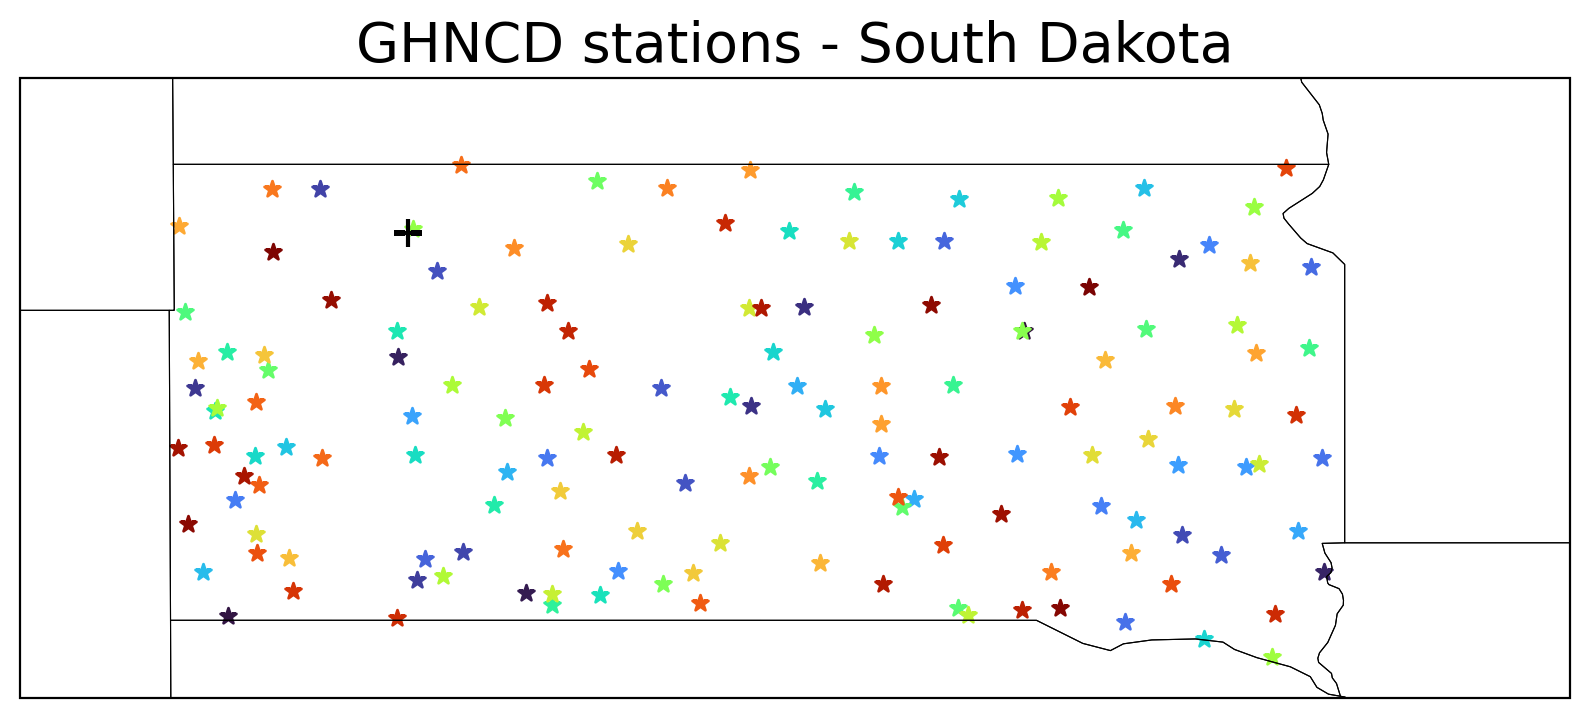

In [ ]:
cmap=cmaps.BlGrYeOrReVi200
proj=ccrs.PlateCarree()
colors=cm.get_cmap('turbo',len(dsSD['station']))
#colors=cm.get_cmap('turbo',10)

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(10,9),subplot_kw={'projection':proj})

for ip in range(0,len(dsSD['station'])):
  ax.scatter(dsSD['longitude'][ip],dsSD['latitude'][ip],marker='*',color=colors(ip),label=dsSD['station'][ip].data.item())
ax.scatter(257.5,45.5,marker='+',color='k',s=100,label='Pt of Interest')
ptlon=[257.5]
ptlat=[45.5]
ax.set_extent([255,265,42.5,46.5],proj)
ax.add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
#handles, labels = ax.get_legend_handles_labels()
#fig.legend(handles, labels, loc='lower center',ncol=6,bbox_to_anchor=(0.5,0.15),prop={'size': 10})
ax.set_title('GHNCD stations - South Dakota',fontsize=20)

In [76]:
CB_color = ['#377eb8', '#ff7f00', '#4daf4a',
            '#e41a1c', '#a65628', '#984ea3',
            '#f781bf', '#dede00', '#999999']

# Pt 1

# Read ERA5 

In [ ]:
ij=0
ilon=ptlon[ij]
ilat=ptlat[ij]
txx=ds['TXx'].sel(lon=ilon,lat=ilat)

# Read GHCND

In [86]:
istation=72
olon=round(dsSD['longitude'].isel(station=72).data.item()+360,2)
olat=round(dsSD['latitude'].isel(station=72).data.item(),2)
Otxx=Octmax.isel(station=72)

Text(0.5, 1.0, 'Annual Maximum Daily Maximum Temperature (TXx)')

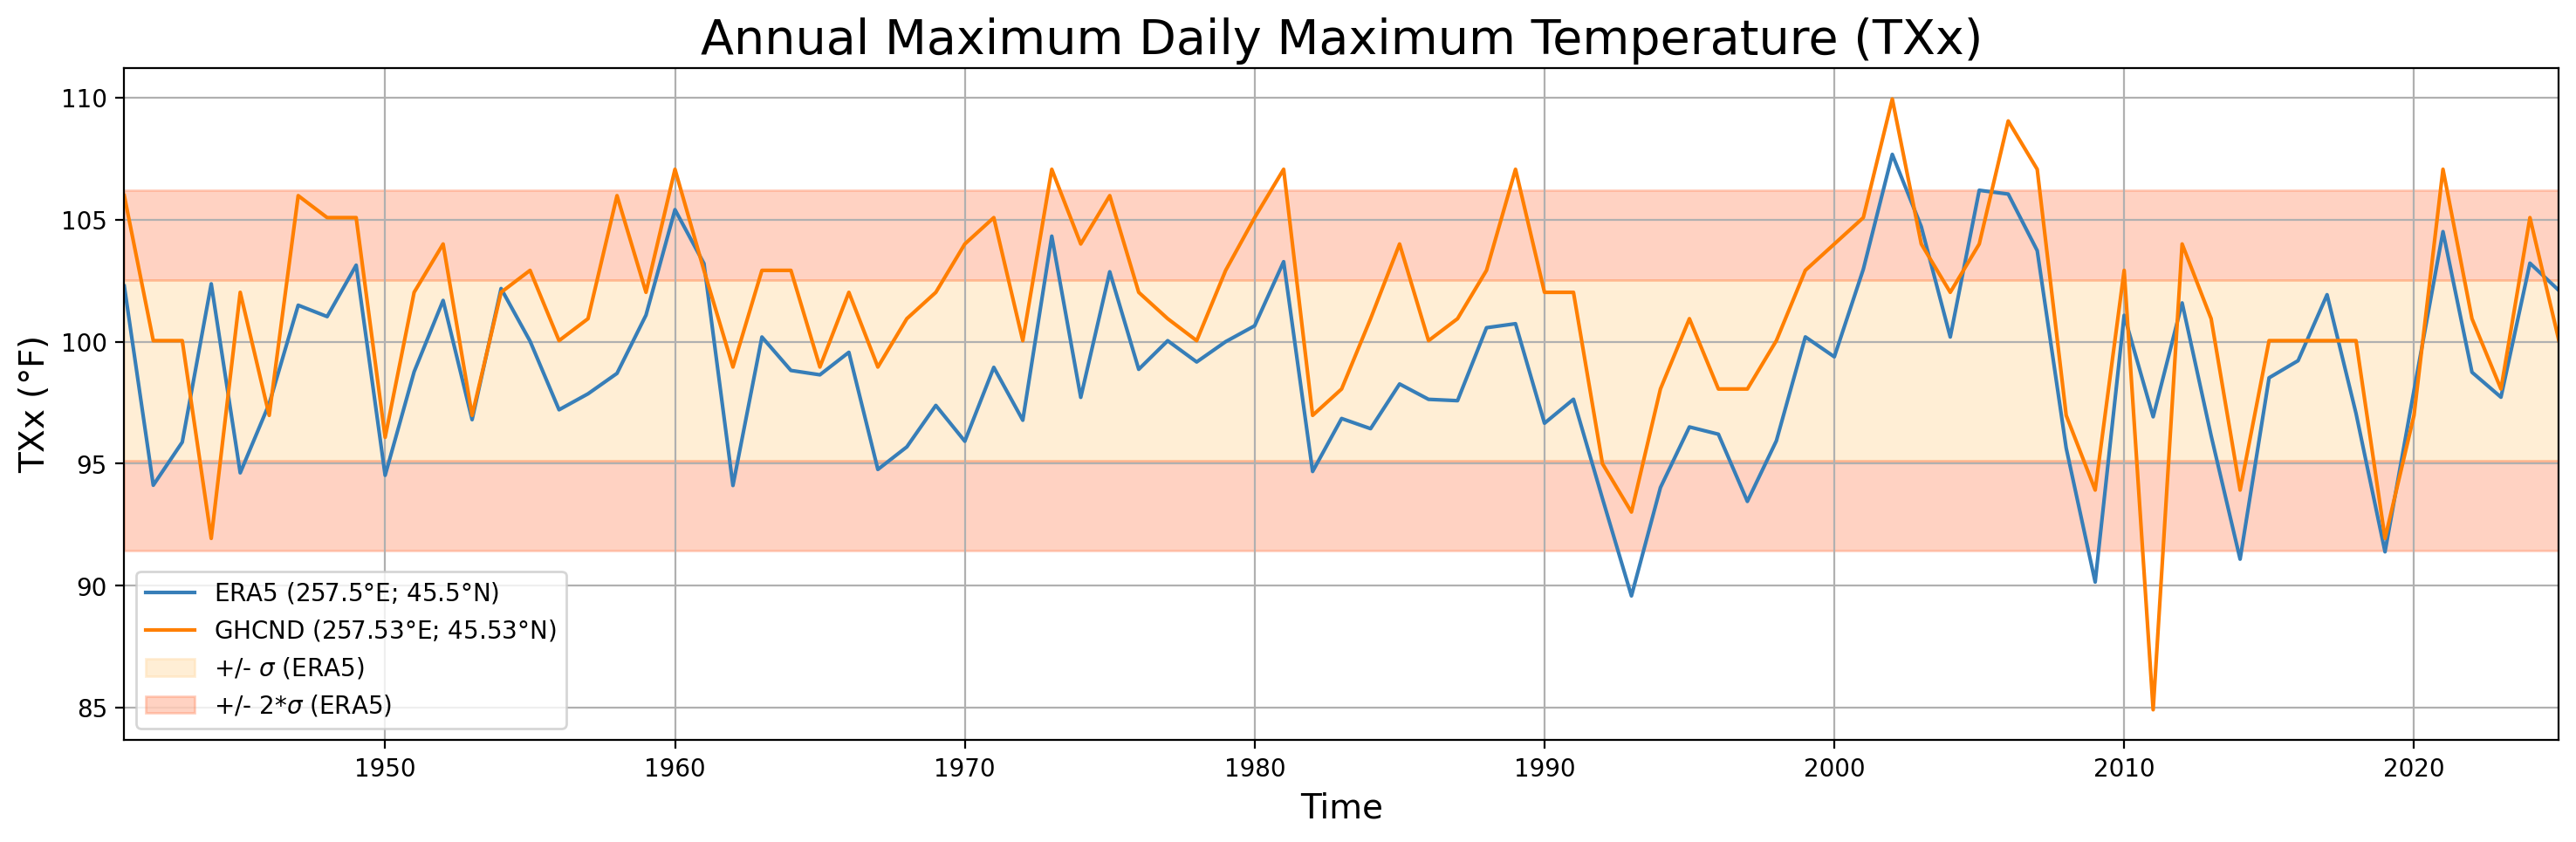

In [88]:
x = txx['time']
y1 = txx.mean('time')-txx.std('time')
y2 = txx.mean('time')+txx.std('time')
y3 = txx.mean('time')-2*txx.std('time')
y4 = txx.mean('time')+2*txx.std('time')
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(18,5))
txx.plot(color=CB_color[0],label=f'ERA5 ({ilon}$\degree$E; {ilat}$\degree$N)')
Otxx.plot(color=CB_color[1],label=f'GHCND ({olon}$\degree$E; {olat}$\degree$N)')
ax.fill_between(x, y1, y2, color='navajowhite', alpha=0.5,label='+/- $\sigma$ (ERA5)')
ax.fill_between(x, y2, y4, color='coral', alpha=0.35,label='+/- 2*$\sigma$ (ERA5)')
ax.fill_between(x, y1, y3, color='coral', alpha=0.35)
ax.set_ylabel(f'TXx ({units})',fontsize=14)
ax.set_xlabel('Time',fontsize=14)
ax.grid()
# set y axis lim
ax.set_xlim(x.min(),x.max())
# show legend
ax.legend()
ax.set_title(f'Annual Maximum Daily Maximum Temperature (TXx)',fontsize=20)

Text(0.5, 1.0, 'Daily Maximum Temperature, GHCND (257.53$\\degree$E; 45.53$\\degree$N)')

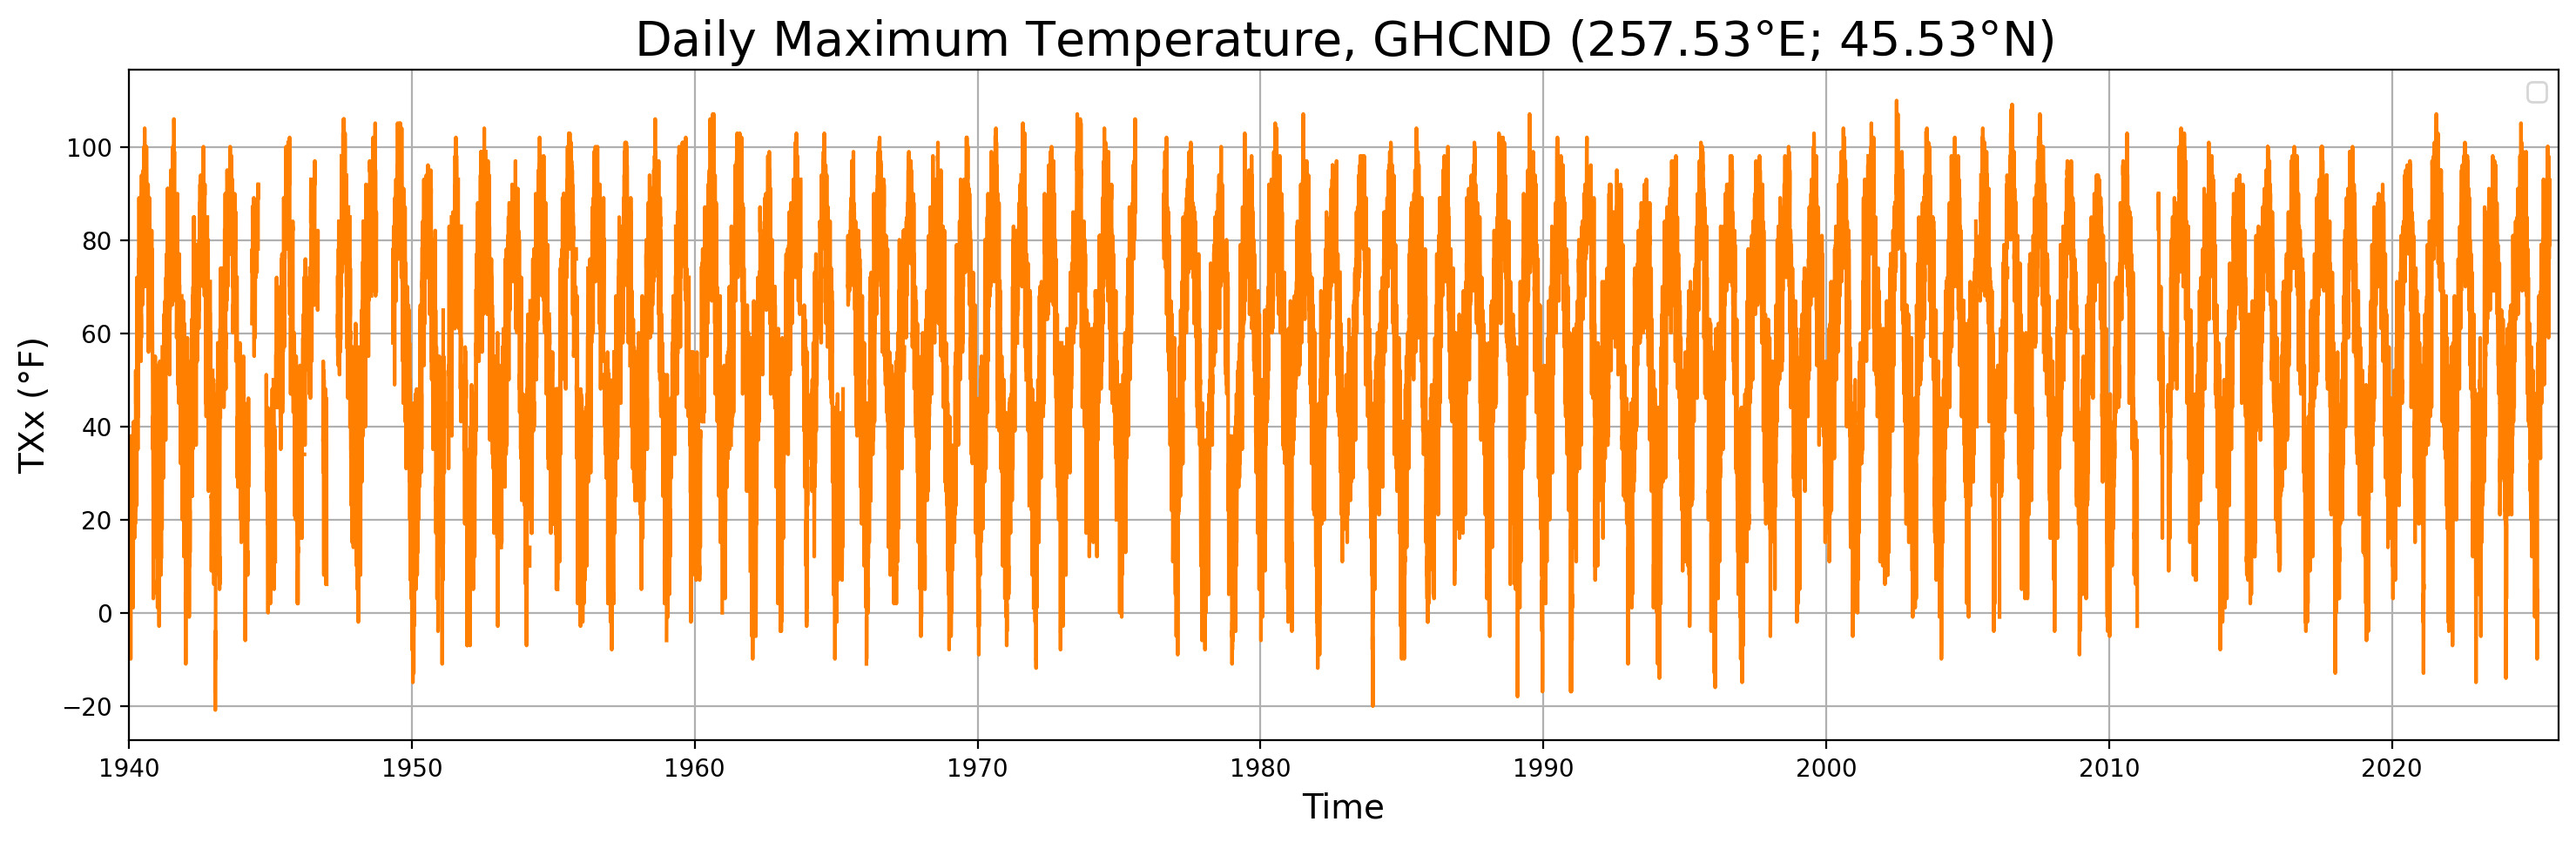

In [91]:

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(18,5))
Otmax.isel(station=72).plot(color=CB_color[1])
ax.set_ylabel(f'TXx ({units})',fontsize=14)
ax.set_xlabel('Time',fontsize=14)
ax.grid()
ax.set_xlim(Otmax['time'].min(),Otmax['time'].max())
ax.legend()
ax.set_title(f'Daily Maximum Temperature, GHCND ({olon}$\degree$E; {olat}$\degree$N)',fontsize=20)